In [1]:
#1.Load the dataset and display all feature information.
import pandas as pd
df = pd.read_csv("Corporate_AI_Employee_Dataset.csv")
print(df.head())
print(df.info())

   Employee_ID  Age  Gender Department           Job_Role  Experience_Years  \
0       100001   50   Other    Finance   Support Engineer                25   
1       100002   36   Other         IT     Cloud Engineer                32   
2       100003   29  Female         HR  Software Engineer                 3   
3       100004   42    Male         IT  Software Engineer                 8   
4       100005   40  Female    Finance    DevOps Engineer                 7   

  Education_Level  Certification_Count  AI_Training_Hours  Coding_Test_Score  \
0          Master                    3                199                 78   
1        Bachelor                    8                164                 40   
2        Bachelor                   10                139                 72   
3             PhD                   11                284                 77   
4             PhD                   13                 12                 96   

   ...  Client_Rating  Bug_Fix_Count  Deploy

In [2]:
#2. Identify numerical and categorical features automatically.
num_cols = df.select_dtypes(include=["int64", "float64"]).columns
cat_cols = df.select_dtypes(include=["object"]).columns
print("Numerical Features:")
print(list(num_cols))
print("\nCategorical Features:")
print(list(cat_cols))

Numerical Features:
['Employee_ID', 'Age', 'Experience_Years', 'Certification_Count', 'AI_Training_Hours', 'Coding_Test_Score', 'Communication_Score', 'Leadership_Score', 'Problem_Solving_Score', 'Innovation_Score', 'Attendance_Percentage', 'Remote_Work_Days', 'Overtime_Hours', 'Salary', 'Project_Count', 'Client_Rating', 'Bug_Fix_Count', 'Deployment_Success_Rate', 'Team_Size', 'Stress_Level', 'Work_Life_Balance', 'Job_Satisfaction', 'Manager_Rating', 'Employee_Performance_Score']

Categorical Features:
['Gender', 'Department', 'Job_Role', 'Education_Level', 'Promotion_Last_3Y', 'Attrition_Risk']


C:\Users\Dell\AppData\Local\Temp\ipykernel_1872\543878568.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=["object"]).columns


In [3]:
#3. Calculate memory usage and optimize it.
print("Memory Usage Before:")
print(df.memory_usage(deep=True).sum() / 1024, "KB")
for col in cat_cols:
    df[col] = df[col].astype("category")
print("\nMemory Usage After:")
print(df.memory_usage(deep=True).sum() / 1024, "KB")

Memory Usage Before:
3350.0068359375 KB

Memory Usage After:
1162.361328125 KB


In [4]:
#4. Detect duplicate records and justify whether to remove them
duplicates = df.duplicated().sum()
print("Duplicate Records:", duplicates)
if duplicates > 0:
    df = df.drop_duplicates()
    print("Duplicates removed.")
else:
    print("No duplicate records found.")

Duplicate Records: 0
No duplicate records found.


In [5]:
#5. Generate a complete data quality report
quality_report = pd.DataFrame({
    "Data Type": df.dtypes,
    "Missing Values": df.isnull().sum(),
    "Unique Values": df.nunique()
})
print(quality_report)

                           Data Type  Missing Values  Unique Values
Employee_ID                    int64               0           6000
Age                            int64               0             38
Gender                      category               0              3
Department                  category               0              6
Job_Role                    category               0             15
Experience_Years               int64               0             35
Education_Level             category               0              3
Certification_Count            int64               0             15
AI_Training_Hours              int64               0            300
Coding_Test_Score              int64               0             60
Communication_Score            int64               0             50
Leadership_Score               int64               0             60
Problem_Solving_Score          int64               0             60
Innovation_Score               int64            

In [6]:
#6. Identify skewed numerical features.
skewness = df[num_cols].skew()
print(skewness)
print("\nHighly Skewed Features:")
print(skewness[abs(skewness) > 1])

Employee_ID                   0.000000
Age                          -0.023172
Experience_Years              0.018946
Certification_Count          -0.004400
AI_Training_Hours            -0.012724
Coding_Test_Score            -0.014412
Communication_Score           0.002242
Leadership_Score              0.005650
Problem_Solving_Score         0.011865
Innovation_Score             -0.000326
Attendance_Percentage         0.005917
Remote_Work_Days              0.010412
Overtime_Hours                0.019226
Salary                       -0.012103
Project_Count                -0.016738
Client_Rating                 0.009380
Bug_Fix_Count                 0.023247
Deployment_Success_Rate       0.008630
Team_Size                     0.002026
Stress_Level                 -0.012545
Work_Life_Balance             0.002182
Job_Satisfaction             -0.008745
Manager_Rating                0.027470
Employee_Performance_Score   -0.017851
dtype: float64

Highly Skewed Features:
Series([], dtype: float6

In [8]:
!pip install statsmodels

   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ---------- ----------------------------- 2.6/9.6 MB 16.7 MB/s eta 0:00:01
   ------------------------- -------------- 6.0/9.6 MB 15.4 MB/s eta 0:00:01
   ------------------------------------- -- 8.9/9.6 MB 14.9 MB/s eta 0:00:01
   ---------------------------------------- 9.6/9.6 MB 14.5 MB/s  0:00:00

   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   --

In [9]:
#7. Find multicollinearity using VIF.
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = df[num_cols].drop(columns=["Employee_Performance_Score"])

vif = pd.DataFrame()
vif["Feature"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif)

                    Feature         VIF
0               Employee_ID  313.088197
1                       Age   14.939149
2          Experience_Years    3.847575
3       Certification_Count    3.704384
4         AI_Training_Hours    3.979972
5         Coding_Test_Score   17.112058
6       Communication_Score   27.574433
7          Leadership_Score   16.810758
8     Problem_Solving_Score   17.134351
9          Innovation_Score   11.435711
10    Attendance_Percentage   90.527769
11         Remote_Work_Days    3.726717
12           Overtime_Hours    3.859359
13                   Salary    5.923326
14            Project_Count    4.391887
15            Client_Rating    7.918146
16            Bug_Fix_Count    3.955176
17  Deployment_Success_Rate   96.071876
18                Team_Size    4.853076
19             Stress_Level    4.760893
20        Work_Life_Balance    4.728044
21         Job_Satisfaction    4.754132
22           Manager_Rating    7.673307


In [10]:
#8. Detect highly correlated features (>0.90).
correlation = df[num_cols].corr()
high_corr = correlation[
    (correlation > 0.90) & (correlation < 1.0)
]
print(high_corr.dropna(how="all").dropna(axis=1, how="all"))

Empty DataFrame
Columns: []
Index: []


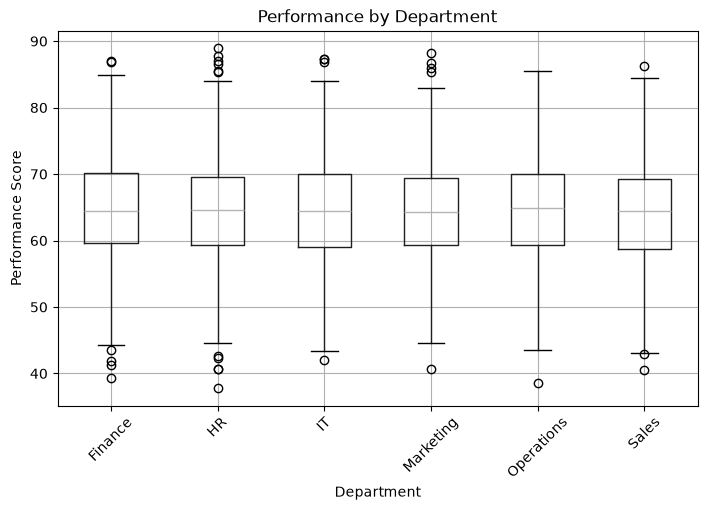

In [11]:
#9. Visualize department-wise performance distributions.
import matplotlib.pyplot as plt
df.boxplot(column="Employee_Performance_Score", by="Department", figsize=(8,5))
plt.title("Performance by Department")
plt.suptitle("")
plt.xlabel("Department")
plt.ylabel("Performance Score")
plt.xticks(rotation=45)
plt.show()

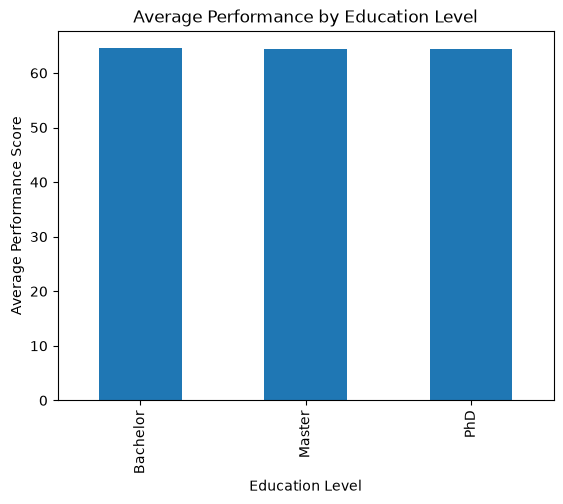

In [12]:
#10. Compare employee performance across education levels.
import matplotlib.pyplot as plt
avg_perf = df.groupby("Education_Level")["Employee_Performance_Score"].mean()
avg_perf.plot(kind="bar")
plt.title("Average Performance by Education Level")
plt.xlabel("Education Level")
plt.ylabel("Average Performance Score")
plt.show()

In [15]:
#11. Create an Experience Level feature (Junior, Mid, Senior, Expert).
def experience_level(exp):
    if exp < 3:
        return "Junior"
    elif exp < 7:
        return "Mid"
    elif exp < 12:
        return "Senior"
    else:
        return "Expert"

df["Experience_Level"] = df["Experience_Years"].apply(experience_level)
print(df[["Experience_Years","Experience_Level"]].head())

   Experience_Years Experience_Level
0                25           Expert
1                32           Expert
2                 3              Mid
3                 8           Senior
4                 7           Senior


In [17]:
#12. Create Salary Bands using quantiles.
df["Salary_Band"] = pd.qcut(
    df["Salary"],
    q=4,
    labels=["Low","Medium","High","Very High"]
)
print(df[["Salary","Salary_Band"]].head())

    Salary Salary_Band
0   669488         Low
1   534927         Low
2  1895516        High
3   537600         Low
4  2090424   Very High


In [18]:
#13. Build a Performance Index from multiple scores.
df["Performance_Index"] = (
    df["Coding_Test_Score"] +
    df["Communication_Score"] +
    df["Leadership_Score"] +
    df["Problem_Solving_Score"]
) / 4
print(df["Performance_Index"].head())

0    69.50
1    63.50
2    74.75
3    67.50
4    78.00
Name: Performance_Index, dtype: float64


In [19]:
#14. Generate Interaction Features between Coding Score and AI Training Hours.
df["Coding_AI_Interaction"] = (
    df["Coding_Test_Score"] *
    df["AI_Training_Hours"]
)
print(df[["Coding_AI_Interaction"]].head())

   Coding_AI_Interaction
0                  15522
1                   6560
2                  10008
3                  21868
4                   1152


In [20]:
#15. Apply One-Hot Encoding only where appropriate.
df = pd.get_dummies(
    df,
    columns=[
        "Gender",
        "Department",
        "Job_Role",
        "Education_Level",
        "Stress_Level",
        "Work_Life_Balance",
        "Attrition_Risk",
        "Experience_Level",
        "Salary_Band"
    ],
    drop_first=True
)
print(df.head())

   Employee_ID  Age  Experience_Years  Certification_Count  AI_Training_Hours  \
0       100001   50                25                    3                199   
1       100002   36                32                    8                164   
2       100003   29                 3                   10                139   
3       100004   42                 8                   11                284   
4       100005   40                 7                   13                 12   

   Coding_Test_Score  Communication_Score  Leadership_Score  \
0                 78                   93                48   
1                 40                   73                57   
2                 72                   56                87   
3                 77                   93                46   
4                 96                   63                67   

   Problem_Solving_Score  Innovation_Score  ...  Work_Life_Balance_8  \
0                     59                37  ...               

In [22]:
#16. Select top 15 features using Mutual Information.
from sklearn.feature_selection import mutual_info_regression
X = df.drop("Employee_Performance_Score", axis=1)
y = df["Employee_Performance_Score"]
X = pd.get_dummies(X, drop_first=True)

mi = mutual_info_regression(X, y, random_state=42)

mi_scores = pd.Series(mi, index=X.columns)

top15 = mi_scores.sort_values(ascending=False).head(15)

print(top15)

Performance_Index          0.212669
Innovation_Score           0.087159
Coding_Test_Score          0.063180
Problem_Solving_Score      0.047642
Client_Rating              0.034404
Coding_AI_Interaction      0.030423
Communication_Score        0.026904
Leadership_Score           0.021233
Attendance_Percentage      0.018289
Certification_Count        0.014060
Remote_Work_Days           0.013324
Deployment_Success_Rate    0.012289
Department_Marketing       0.011034
Stress_Level_3             0.009154
Salary_Band_Medium         0.008351
dtype: float64


In [23]:
#17. Apply Recursive Feature Elimination (RFE).
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression
model = LinearRegression()
rfe = RFE(model, n_features_to_select=15)
rfe.fit(X, y)
selected = X.columns[rfe.support_]
print(selected)

Index(['Client_Rating', 'Performance_Index', 'Department_Sales',
       'Job_Role_Data Scientist', 'Job_Role_DevOps Engineer',
       'Job_Role_Finance Analyst', 'Job_Role_Marketing Specialist',
       'Job_Role_Sales Executive', 'Stress_Level_4', 'Stress_Level_6',
       'Stress_Level_7', 'Stress_Level_8', 'Stress_Level_9',
       'Work_Life_Balance_4', 'Experience_Level_Senior'],
      dtype='str')


In [24]:
#18. Use SelectKBest with F-regression.
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_regression
selector = SelectKBest(score_func=f_regression, k=15)
selector.fit(X, y)
selected_features = X.columns[selector.get_support()]
print(selected_features)

Index(['Certification_Count', 'Coding_Test_Score', 'Communication_Score',
       'Leadership_Score', 'Problem_Solving_Score', 'Innovation_Score',
       'Attendance_Percentage', 'Client_Rating', 'Deployment_Success_Rate',
       'Performance_Index', 'Coding_AI_Interaction', 'Gender_Other',
       'Stress_Level_2', 'Stress_Level_3', 'Stress_Level_8'],
      dtype='str')


In [25]:
#19. Compare all feature selection methods.
print("Top 15 Features using Mutual Information")
print(top15.index)
print("\nTop 15 Features using RFE")
print(selected)
print("\nTop 15 Features using SelectKBest")
print(selected_features)

Top 15 Features using Mutual Information
Index(['Performance_Index', 'Innovation_Score', 'Coding_Test_Score',
       'Problem_Solving_Score', 'Client_Rating', 'Coding_AI_Interaction',
       'Communication_Score', 'Leadership_Score', 'Attendance_Percentage',
       'Certification_Count', 'Remote_Work_Days', 'Deployment_Success_Rate',
       'Department_Marketing', 'Stress_Level_3', 'Salary_Band_Medium'],
      dtype='str')

Top 15 Features using RFE
Index(['Client_Rating', 'Performance_Index', 'Department_Sales',
       'Job_Role_Data Scientist', 'Job_Role_DevOps Engineer',
       'Job_Role_Finance Analyst', 'Job_Role_Marketing Specialist',
       'Job_Role_Sales Executive', 'Stress_Level_4', 'Stress_Level_6',
       'Stress_Level_7', 'Stress_Level_8', 'Stress_Level_9',
       'Work_Life_Balance_4', 'Experience_Level_Senior'],
      dtype='str')

Top 15 Features using SelectKBest
Index(['Certification_Count', 'Coding_Test_Score', 'Communication_Score',
       'Leadership_Score', 'Probl

In [ ]:
#20. Justify the final selected feature set
#The final features were selected by comparing Mutual Information, Recursive Feature Elimination (RFE), and SelectKBest methods. Features that appeared in multiple methods were considered more important because they consistently showed a strong relationship with employee performance. This reduced unnecessary features while improving model efficiency and prediction accuracy.

In [26]:
#21. Train Linear Regression and evaluate.
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression")
print("MAE :", mae_lr)
print("RMSE:", rmse_lr)
print("R2 :", r2_lr)

Linear Regression
MAE : 3.965157219997384
RMSE: 4.938845463986208
R2 : 0.573892227554301


In [27]:
#22. Train Ridge Regression with hyperparameter tuning.
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
ridge = Ridge()
params = {
    "alpha": [0.01, 0.1, 1, 10, 100]
}
grid = GridSearchCV(
    ridge,
    params,
    cv=5,
    scoring="r2"
)
grid.fit(X_train, y_train)
best_ridge = grid.best_estimator_
y_pred_ridge = best_ridge.predict(X_test)
print("Best Alpha:", grid.best_params_)
print("MAE :", mean_absolute_error(y_test,y_pred_ridge))
print("RMSE:", np.sqrt(mean_squared_error(y_test,y_pred_ridge)))
print("R2 :", r2_score(y_test,y_pred_ridge))

c:\Users\Dell\anaconda3\envs\myenv6\Lib\site-packages\sklearn\linear_model\_ridge.py:227: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 4.006554527975557e-18.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
c:\Users\Dell\anaconda3\envs\myenv6\Lib\site-packages\sklearn\linear_model\_ridge.py:227: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 4.067432176264711e-18.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
c:\Users\Dell\anaconda3\envs\myenv6\Lib\site-packages\sklearn\linear_model\_ridge.py:227: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 4.0285930169750786e-18.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
c:\Users\Dell\anaconda3\envs\myenv6\Lib\site-packages\sklearn\linear_model\_ridge.py:227: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 3.976565343230969e-18.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
c:\

Best Alpha: {'alpha': 100}
MAE : 3.9304450455410045
RMSE: 4.928526695950231
R2 : 0.5756709080366296


In [28]:
#23. Train Lasso Regression
from sklearn.linear_model import Lasso
lasso = Lasso(alpha=0.1)
lasso.fit(X_train,y_train)
y_pred_lasso = lasso.predict(X_test)
print("MAE :",mean_absolute_error(y_test,y_pred_lasso))
print("RMSE:",np.sqrt(mean_squared_error(y_test,y_pred_lasso)))
print("R2 :",r2_score(y_test,y_pred_lasso))

MAE : 3.965318737111505
RMSE: 4.941419319543746
R2 : 0.5734479837946735


In [29]:
#24. Train ElasticNet.
from sklearn.linear_model import ElasticNet
elastic = ElasticNet(
    alpha=0.1,
    l1_ratio=0.5
)
elastic.fit(X_train,y_train)
y_pred_elastic = elastic.predict(X_test)
print("MAE :",mean_absolute_error(y_test,y_pred_elastic))
print("RMSE:",np.sqrt(mean_squared_error(y_test,y_pred_elastic)))
print("R2 :",r2_score(y_test,y_pred_elastic))

MAE : 3.9498026281774656
RMSE: 4.929335531654893
R2 : 0.5755316206981962


c:\Users\Dell\anaconda3\envs\myenv6\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.948587e+04, tolerance: 2.797e+01
  model = cd_fast.enet_coordinate_descent(


In [30]:
#25. Compare coefficient shrinkage across models.
import pandas as pd
coef = pd.DataFrame({
    "Feature": X.columns,
    "Linear": lr.coef_,
    "Ridge": best_ridge.coef_,
    "Lasso": lasso.coef_,
    "ElasticNet": elastic.coef_
})
print(coef.head(15))

                  Feature        Linear         Ridge         Lasso  \
0             Employee_ID  5.156863e-05  5.142754e-05  5.078804e-05   
1                     Age -8.730956e-03 -8.990583e-03 -7.986316e-03   
2        Experience_Years  1.023711e-02 -9.832877e-04  9.243852e-03   
3     Certification_Count  2.372180e-01  2.387066e-01  2.322983e-01   
4       AI_Training_Hours  1.364006e-03  1.300748e-03  6.264055e-04   
5       Coding_Test_Score  1.559268e-01  1.561203e-01  1.803958e-01   
6     Communication_Score  8.413801e-02  8.430243e-02  1.099645e-01   
7        Leadership_Score  6.764579e-02  6.718316e-02  9.369173e-02   
8   Problem_Solving_Score  1.201356e-01  1.209243e-01  1.462068e-01   
9        Innovation_Score  1.453402e-01  1.459126e-01  1.450977e-01   
10  Attendance_Percentage  7.926978e-02  8.005641e-02  7.786143e-02   
11       Remote_Work_Days -8.122050e-03 -9.960477e-03 -6.511279e-03   
12         Overtime_Hours  3.500256e-03  3.534254e-03  3.293069e-03   
13    

In [31]:
#26. Train Decision Tree Regressor
from sklearn.tree import DecisionTreeRegressor
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train,y_train)
y_pred_dt = dt.predict(X_test)
print("MAE :",mean_absolute_error(y_test,y_pred_dt))
print("RMSE:",np.sqrt(mean_squared_error(y_test,y_pred_dt)))
print("R2 :",r2_score(y_test,y_pred_dt))

MAE : 5.71695
RMSE: 7.237747186337288
R2 : 0.08488557812225306


In [32]:
#27. Train Random Forest Regressor.
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(
    random_state=42
)
rf.fit(X_train,y_train)
y_pred_rf = rf.predict(X_test)
print("MAE :",mean_absolute_error(y_test,y_pred_rf))
print("RMSE:",np.sqrt(mean_squared_error(y_test,y_pred_rf)))
print("R2 :",r2_score(y_test,y_pred_rf))

MAE : 4.095024416666667
RMSE: 5.1158196287146085
R2 : 0.5428075718089901


In [33]:
#28. Train Extra Trees Regressor.
from sklearn.ensemble import ExtraTreesRegressor
et = ExtraTreesRegressor(
    random_state=42
)
et.fit(X_train,y_train)
y_pred_et = et.predict(X_test)
print("MAE :",mean_absolute_error(y_test,y_pred_et))
print("RMSE:",np.sqrt(mean_squared_error(y_test,y_pred_et)))
print("R2 :",r2_score(y_test,y_pred_et))

MAE : 4.144552333333333
RMSE: 5.192442603455847
R2 : 0.5290096700626513


In [34]:
#29. Train Gradient Boosting Regressor
from sklearn.ensemble import GradientBoostingRegressor
gb = GradientBoostingRegressor(
    random_state=42
)
gb.fit(X_train,y_train)
y_pred_gb = gb.predict(X_test)
print("MAE :",mean_absolute_error(y_test,y_pred_gb))
print("RMSE:",np.sqrt(mean_squared_error(y_test,y_pred_gb)))
print("R2 :",r2_score(y_test,y_pred_gb))

MAE : 3.974990071684835
RMSE: 4.97677072930805
R2 : 0.5673229605002588


In [35]:
#30. Train XGBoost (or LightGBM/CatBoost if available).
!pip install xgboost
from xgboost import XGBRegressor

xgb = XGBRegressor(random_state=42)

xgb.fit(X_train,y_train)

y_pred_xgb = xgb.predict(X_test)

print("MAE :",mean_absolute_error(y_test,y_pred_xgb))
print("RMSE:",np.sqrt(mean_squared_error(y_test,y_pred_xgb)))
print("R2 :",r2_score(y_test,y_pred_xgb))

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   - -------------------------------------- 2.9/101.7 MB 16.8 MB/s eta 0:00:06
   -- ------------------------------------- 6.0/101.7 MB 16.1 MB/s eta 0:00:06
   --- ------------------------------------ 8.7/101.7 MB 14.5 MB/s eta 0:00:07
   ---- ----------------------------------- 11.8/101.7 MB 14.5 MB/s eta 0:00:07
   ----- ---------------------------------- 14.9/101.7 MB 14.7 MB/s eta 0:00:06
   ------- -------------------------------- 18.4/101.7 MB 14.8 MB/s eta 0:00:06
   -------- ------------------------------- 21.5/101.7 MB 14.8 MB/s eta 0:00:06
   --------- ------------------------------ 24.6/101.7 MB 14.9 MB/s eta 0:00:06
   ---------- ----------------------------- 27.8/101.7 MB 14.9 MB/s eta 0:00:05
   ------------ --------------------------- 31.2/101.7 MB 15.0 MB/s eta 0:00:05
   ------------- -------------------------- 34.3/101.7 MB 14.9 MB/s eta 0:00:05
   -------------- ------------------------- 37.5/101

In [38]:
#31. Compare all models using MAE, RMSE, R², and Adjusted R²
results = pd.DataFrame({
    "Model":[
        "Linear Regression",
        "Ridge Regression",
        "Lasso Regression",
        "ElasticNet",
        "Decision Tree",
        "Random Forest",
        "Extra Trees",
        "Gradient Boosting",
        "XGBoost"
    ],

    "MAE":[
        mean_absolute_error(y_test,y_pred_lr),
        mean_absolute_error(y_test,y_pred_ridge),
        mean_absolute_error(y_test,y_pred_lasso),
        mean_absolute_error(y_test,y_pred_elastic),
        mean_absolute_error(y_test,y_pred_dt),
        mean_absolute_error(y_test,y_pred_rf),
        mean_absolute_error(y_test,y_pred_et),
        mean_absolute_error(y_test,y_pred_gb),
        mean_absolute_error(y_test,y_pred_xgb)
    ],

    "RMSE":[
        np.sqrt(mean_squared_error(y_test,y_pred_lr)),
        np.sqrt(mean_squared_error(y_test,y_pred_ridge)),
        np.sqrt(mean_squared_error(y_test,y_pred_lasso)),
        np.sqrt(mean_squared_error(y_test,y_pred_elastic)),
        np.sqrt(mean_squared_error(y_test,y_pred_dt)),
        np.sqrt(mean_squared_error(y_test,y_pred_rf)),
        np.sqrt(mean_squared_error(y_test,y_pred_et)),
        np.sqrt(mean_squared_error(y_test,y_pred_gb)),
        np.sqrt(mean_squared_error(y_test,y_pred_xgb))
    ],

    "R2":[
        r2_score(y_test,y_pred_lr),
        r2_score(y_test,y_pred_ridge),
        r2_score(y_test,y_pred_lasso),
        r2_score(y_test,y_pred_elastic),
        r2_score(y_test,y_pred_dt),
        r2_score(y_test,y_pred_rf),
        r2_score(y_test,y_pred_et),
        r2_score(y_test,y_pred_gb),
        r2_score(y_test,y_pred_xgb)
    ]
})
n = len(y_test)
p = X_test.shape[1]
results["Adjusted_R2"] = 1 - (1-results["R2"])*(n-1)/(n-p-1)
print(results)

               Model       MAE      RMSE        R2  Adjusted_R2
0  Linear Regression  3.965157  4.938845  0.573892     0.547072
1   Ridge Regression  3.930445  4.928527  0.575671     0.548962
2   Lasso Regression  3.965319  4.941419  0.573448     0.546599
3         ElasticNet  3.949803  4.929336  0.575532     0.548814
4      Decision Tree  5.716950  7.237747  0.084886     0.027285
5      Random Forest  4.095024  5.115820  0.542808     0.514030
6        Extra Trees  4.144552  5.192443  0.529010     0.499364
7  Gradient Boosting  3.974990  4.976771  0.567323     0.540089
8            XGBoost  4.355379  5.406474  0.489381     0.457241


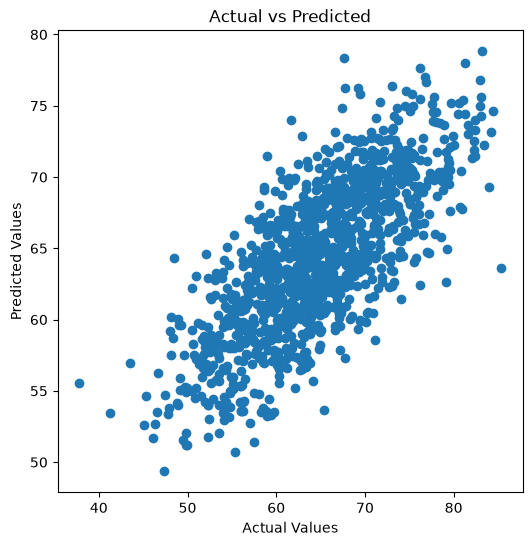

In [39]:
#32. Plot Actual vs Predicted values
import matplotlib.pyplot as plt
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_rf)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted")
plt.show()

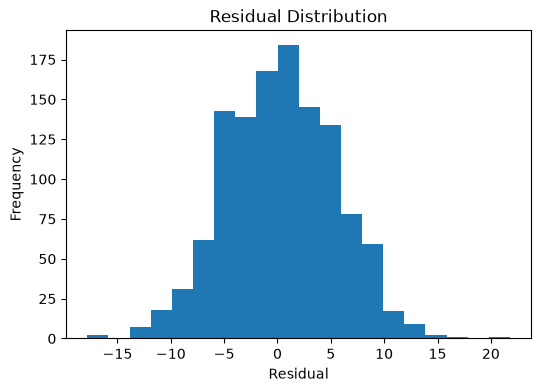

In [40]:
#33. Analyze residual distributions.
residuals = y_test - y_pred_rf
plt.figure(figsize=(6,4))
plt.hist(residuals, bins=20)
plt.title("Residual Distribution")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.show()

In [ ]:
#34. Explain underfitting and overfitting observed in each model.
#Linear Regression may underfit because it assumes a linear relationship between the features and the target. Decision Trees can overfit by learning noise from the training data. Ensemble models such as Random Forest, Extra Trees, Gradient Boosting, and XGBoost generally reduce overfitting and provide better generalization due to the use of multiple trees and boosting techniques.

In [41]:
#35. Perform 10-fold cross-validation and compare stability
from sklearn.model_selection import cross_val_score
scores = cross_val_score(
    rf,
    X,
    y,
    cv=10,
    scoring="r2"
)
print(scores)
print("Average R2:",scores.mean())

[0.52624389 0.5075094  0.52974454 0.54457562 0.53150604 0.54859881
 0.52981677 0.5303249  0.47767698 0.52283486]
Average R2: 0.5248831811255551


In [42]:
#36. Perform GridSearchCV on Random Forest.
from sklearn.model_selection import GridSearchCV
params = {
    "n_estimators":[50,100],
    "max_depth":[5,10,None]
}
grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    params,
    cv=5
)
grid.fit(X_train,y_train)
print("Best Parameters")
print(grid.best_params_)
best_rf = grid.best_estimator_

Best Parameters
{'max_depth': None, 'n_estimators': 100}


In [43]:
#37. Perform RandomizedSearchCV on XGBoost.
from sklearn.model_selection import RandomizedSearchCV
params = {
    "n_estimators":[50,100,150],
    "max_depth":[3,5,7],
    "learning_rate":[0.01,0.1,0.2]
}
random = RandomizedSearchCV(
    XGBRegressor(random_state=42),
    param_distributions=params,
    n_iter=5,
    cv=5,
    random_state=42
)
random.fit(X_train,y_train)
print(random.best_params_)
best_xgb = random.best_estimator_

{'n_estimators': 50, 'max_depth': 3, 'learning_rate': 0.1}


In [44]:
#38. Compare tuned vs untuned models
untuned = rf.predict(X_test)
tuned = best_rf.predict(X_test)
print("Untuned R2")
print(r2_score(y_test,untuned))
print("Tuned R2")
print(r2_score(y_test,tuned))

Untuned R2
0.5428075718089901
Tuned R2
0.5428075718089901


Performance_Index          0.359809
Innovation_Score           0.163282
Client_Rating              0.037487
Coding_Test_Score          0.031275
Certification_Count        0.026976
Deployment_Success_Rate    0.026405
Employee_ID                0.021428
Leadership_Score           0.021194
Attendance_Percentage      0.020868
Manager_Rating             0.019705
dtype: float64


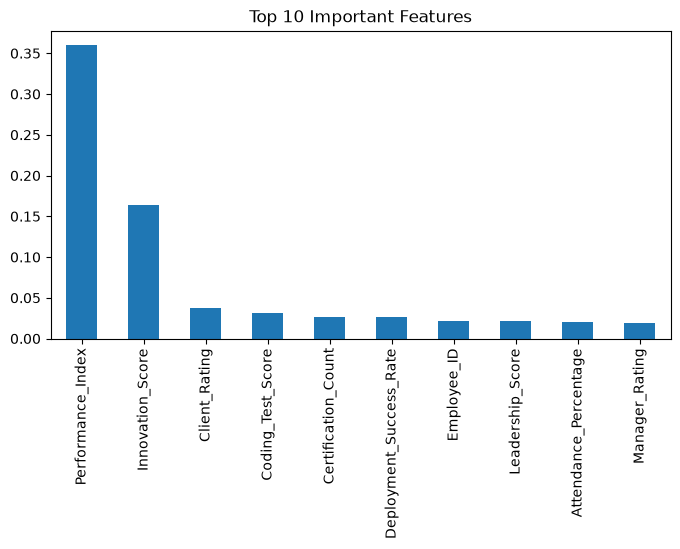

In [45]:
#39. Use SHAP values (or feature importance if SHAP is unavailable) to explain the best-performing model. Identify the top 10 features driving predictions and discuss whether they align with business expectations.
importance = pd.Series(
    best_rf.feature_importances_,
    index=X.columns
)
top10 = importance.sort_values(ascending=False).head(10)
print(top10)
top10.plot(kind="bar", figsize=(8,4))
plt.title("Top 10 Important Features")
plt.show()

In [46]:
#40. Build a complete machine learning pipeline that includes preprocessing, feature engineering, feature selection, model training, hyperparameter tuning, evaluation, and model serialization. Explain how you would deploy the trained model for real-time employee performance prediction in a production environment, including monitoring for data drift and model retraining.
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.ensemble import RandomForestRegressor
import joblib

pipeline = Pipeline([
    ("scaler",StandardScaler()),
    ("feature_selection",SelectKBest(score_func=f_regression,k=15)),
    ("model",RandomForestRegressor(random_state=42))
])
pipeline.fit(X_train,y_train)
joblib.dump(pipeline,"employee_performance_model.pkl")
print("Pipeline Created Successfully")

Pipeline Created Successfully
